<a href="https://colab.research.google.com/github/ahishkh/Oil-geopolitical-risk-analysis/blob/main/CrudeOil_GeopoliticalRisk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Oil/oil_geopolitics_dataset_2010_2026.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head())


(4047, 23)
['date', 'brent_price', 'wti_price', 'dxy_index', 'vix', 'gpr_index', 'brent_return', 'wti_return', 'brent_lag_1', 'brent_lag_3', 'brent_lag_7', 'wti_lag_1', 'wti_lag_3', 'wti_lag_7', 'brent_volatility_7d', 'brent_volatility_30d', 'wti_volatility_7d', 'wti_volatility_30d', 'brent_wti_spread', 'event_type', 'event_description', 'event_severity', 'event_flag']
         date  brent_price  wti_price  dxy_index        vix  gpr_index  \
0  2010-02-17    76.269997  77.330002  80.379997  21.719999  80.725357   
1  2010-02-18    77.779999  79.059998  80.400002  20.629999  80.725357   
2  2010-02-19    78.190002  79.809998  80.639999  20.020000  80.725357   
3  2010-02-22    78.610001  80.160004  80.510002  19.940001  80.725357   
4  2010-02-23    77.250000  78.860001  80.849998  21.370001  80.725357   

   brent_return  wti_return  brent_lag_1  brent_lag_3  ...  wti_lag_7  \
0      0.007796    0.004155    75.680000    73.050003  ...  71.190002   
1      0.019798    0.022372    76.269

In [5]:
df.head()

,date,brent_price,wti_price,dxy_index,vix,gpr_index,brent_return,wti_return,brent_lag_1,brent_lag_3,...,wti_lag_7,brent_volatility_7d,brent_volatility_30d,wti_volatility_7d,wti_volatility_30d,brent_wti_spread,event_type,event_description,event_severity,event_flag
0,2010-02-17,76.269997,77.330002,80.379997,21.719999,80.725357,0.007796,0.004155,75.680000,73.050003,...,71.190002,0.014461,0.019679,0.016977,0.019280,-1.060005,none,none,0.0,0
1,2010-02-18,77.779999,79.059998,80.400002,20.629999,80.725357,0.019798,0.022372,76.269997,72.900002,...,71.889999,0.014387,0.020019,0.017366,0.019756,-1.279999,none,none,0.0,0
2,2010-02-19,78.190002,79.809998,80.639999,20.020000,80.725357,0.005271,0.009486,77.779999,75.680000,...,73.750000,0.013342,0.019796,0.016553,0.019559,-1.619995,none,none,0.0,0
3,2010-02-22,78.610001,80.160004,80.510002,19.940001,80.725357,0.005372,0.004385,78.190002,76.269997,...,74.519997,0.013366,0.019823,0.016772,0.019561,-1.550003,none,none,0.0,0
4,2010-02-23,77.250000,78.860001,80.849998,21.370001,80.725357,-0.017301,-0.016218,78.610001,77.779999,...,75.279999,0.017334,0.020045,0.019608,0.019756,-1.610001,none,none,0.0,0


In [6]:
events=pd.read_csv('/content/drive/MyDrive/Oil/geopolitical_events_timeline.csv')
print(events.shape)
print(df.shape)


(35, 4)
(4047, 23)


In [7]:
events.head()

,date,event_type,event_description,event_severity
0,2010-04-20,disaster,Deepwater Horizon oil spill,7
1,2011-02-15,war,Libyan Civil War begins,9
2,2011-03-19,war,NATO intervention in Libya,9
3,2012-01-23,sanctions,EU embargo on Iranian oil imports,8
4,2014-03-18,annexation,Russia annexes Crimea,8


In [8]:
print("Main dataset shape:", df.shape)
print("\nMain columns:", df.columns.tolist())
print("\nEvents shape:", events.shape)
print("\nEvents columns:", events.columns.tolist())

Main dataset shape: (4047, 23)

Main columns: ['date', 'brent_price', 'wti_price', 'dxy_index', 'vix', 'gpr_index', 'brent_return', 'wti_return', 'brent_lag_1', 'brent_lag_3', 'brent_lag_7', 'wti_lag_1', 'wti_lag_3', 'wti_lag_7', 'brent_volatility_7d', 'brent_volatility_30d', 'wti_volatility_7d', 'wti_volatility_30d', 'brent_wti_spread', 'event_type', 'event_description', 'event_severity', 'event_flag']

Events shape: (35, 4)

Events columns: ['date', 'event_type', 'event_description', 'event_severity']


In [9]:
events

,date,event_type,event_description,event_severity
0,2010-04-20,disaster,Deepwater Horizon oil spill,7
1,2011-02-15,war,Libyan Civil War begins,9
2,2011-03-19,war,NATO intervention in Libya,9
3,2012-01-23,sanctions,EU embargo on Iranian oil imports,8
4,2014-03-18,annexation,Russia annexes Crimea,8
5,2014-11-27,opec,OPEC maintains production despite falling prices,9
6,2015-03-26,war,Saudi-led intervention in Yemen,7
7,2016-01-16,sanctions,Iran nuclear sanctions lifted,6
8,2016-09-28,opec,OPEC Algiers agreement on production cuts,8
9,2016-11-30,opec,First OPEC+ production cut agreement,8


In [10]:
df

,date,brent_price,wti_price,dxy_index,vix,gpr_index,brent_return,wti_return,brent_lag_1,brent_lag_3,...,wti_lag_7,brent_volatility_7d,brent_volatility_30d,wti_volatility_7d,wti_volatility_30d,brent_wti_spread,event_type,event_description,event_severity,event_flag
0,2010-02-17,76.269997,77.330002,80.379997,21.719999,80.725357,0.007796,0.004155,75.680000,73.050003,...,71.190002,0.014461,0.019679,0.016977,0.019280,-1.060005,none,none,0.0,0
1,2010-02-18,77.779999,79.059998,80.400002,20.629999,80.725357,0.019798,0.022372,76.269997,72.900002,...,71.889999,0.014387,0.020019,0.017366,0.019756,-1.279999,none,none,0.0,0
2,2010-02-19,78.190002,79.809998,80.639999,20.020000,80.725357,0.005271,0.009486,77.779999,75.680000,...,73.750000,0.013342,0.019796,0.016553,0.019559,-1.619995,none,none,0.0,0
3,2010-02-22,78.610001,80.160004,80.510002,19.940001,80.725357,0.005372,0.004385,78.190002,76.269997,...,74.519997,0.013366,0.019823,0.016772,0.019561,-1.550003,none,none,0.0,0
4,2010-02-23,77.250000,78.860001,80.849998,21.370001,80.725357,-0.017301,-0.016218,78.610001,77.779999,...,75.279999,0.017334,0.020045,0.019608,0.019756,-1.610001,none,none,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4042,2026-03-06,92.690002,90.900002,98.989998,29.490000,130.887665,0.085236,0.122084,85.410004,81.400002,...,65.419998,0.033662,0.029489,0.045250,0.034029,1.790001,none,none,0.0,0
4043,2026-03-09,98.959999,94.769997,99.180000,25.500000,130.887665,0.067645,0.042574,92.690002,81.400002,...,65.209999,0.029502,0.031034,0.039384,0.034316,4.190002,blockade,Closure of Strait of Hormuz shipping lane,10.0,1
4044,2026-03-10,87.800003,83.449997,98.830002,24.930000,130.887665,-0.112773,-0.119447,98.959999,85.410004,...,67.019997,0.068590,0.038639,0.077506,0.042092,4.350006,none,none,0.0,0
4045,2026-03-11,91.980003,87.250000,99.230003,24.230000,130.887665,0.047608,0.045536,87.800003,92.690002,...,71.230003,0.066619,0.039074,0.076723,0.042435,4.730003,none,none,0.0,0


In [11]:
print("Main dataset shape:", df.shape)
print("\nMain columns:", df.columns.tolist())
print("\nEvents shape:", events.shape)
print("\nEvents columns:", events.columns.tolist())

Main dataset shape: (4047, 23)

Main columns: ['date', 'brent_price', 'wti_price', 'dxy_index', 'vix', 'gpr_index', 'brent_return', 'wti_return', 'brent_lag_1', 'brent_lag_3', 'brent_lag_7', 'wti_lag_1', 'wti_lag_3', 'wti_lag_7', 'brent_volatility_7d', 'brent_volatility_30d', 'wti_volatility_7d', 'wti_volatility_30d', 'brent_wti_spread', 'event_type', 'event_description', 'event_severity', 'event_flag']

Events shape: (35, 4)

Events columns: ['date', 'event_type', 'event_description', 'event_severity']


In [12]:
import matplotlib.pyplot as plt

# Parse dates
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Check nulls
print("Nulls:\n", df.isnull().sum())
print("\nDate range:", df['date'].min(), "to", df['date'].max())
print("\nBasic stats:\n", df[['brent_price','wti_price','vix','gpr_index']].describe())


Nulls:
 date                    0
brent_price             0
wti_price               0
dxy_index               0
vix                     0
gpr_index               0
brent_return            0
wti_return              0
brent_lag_1             0
brent_lag_3             0
brent_lag_7             0
wti_lag_1               0
wti_lag_3               0
wti_lag_7               0
brent_volatility_7d     0
brent_volatility_30d    0
wti_volatility_7d       0
wti_volatility_30d      0
brent_wti_spread        0
event_type              0
event_description       0
event_severity          0
event_flag              0
dtype: int64

Date range: 2010-02-17 00:00:00 to 2026-03-12 00:00:00

Basic stats:
        brent_price    wti_price          vix    gpr_index
count  4047.000000  4047.000000  4047.000000  4047.000000
mean     77.623944    71.417546    18.393249   102.596421
std      23.529261    20.777323     6.853769    31.559190
min      19.330000   -37.630001     9.140000    58.420769
25%      60.785000  

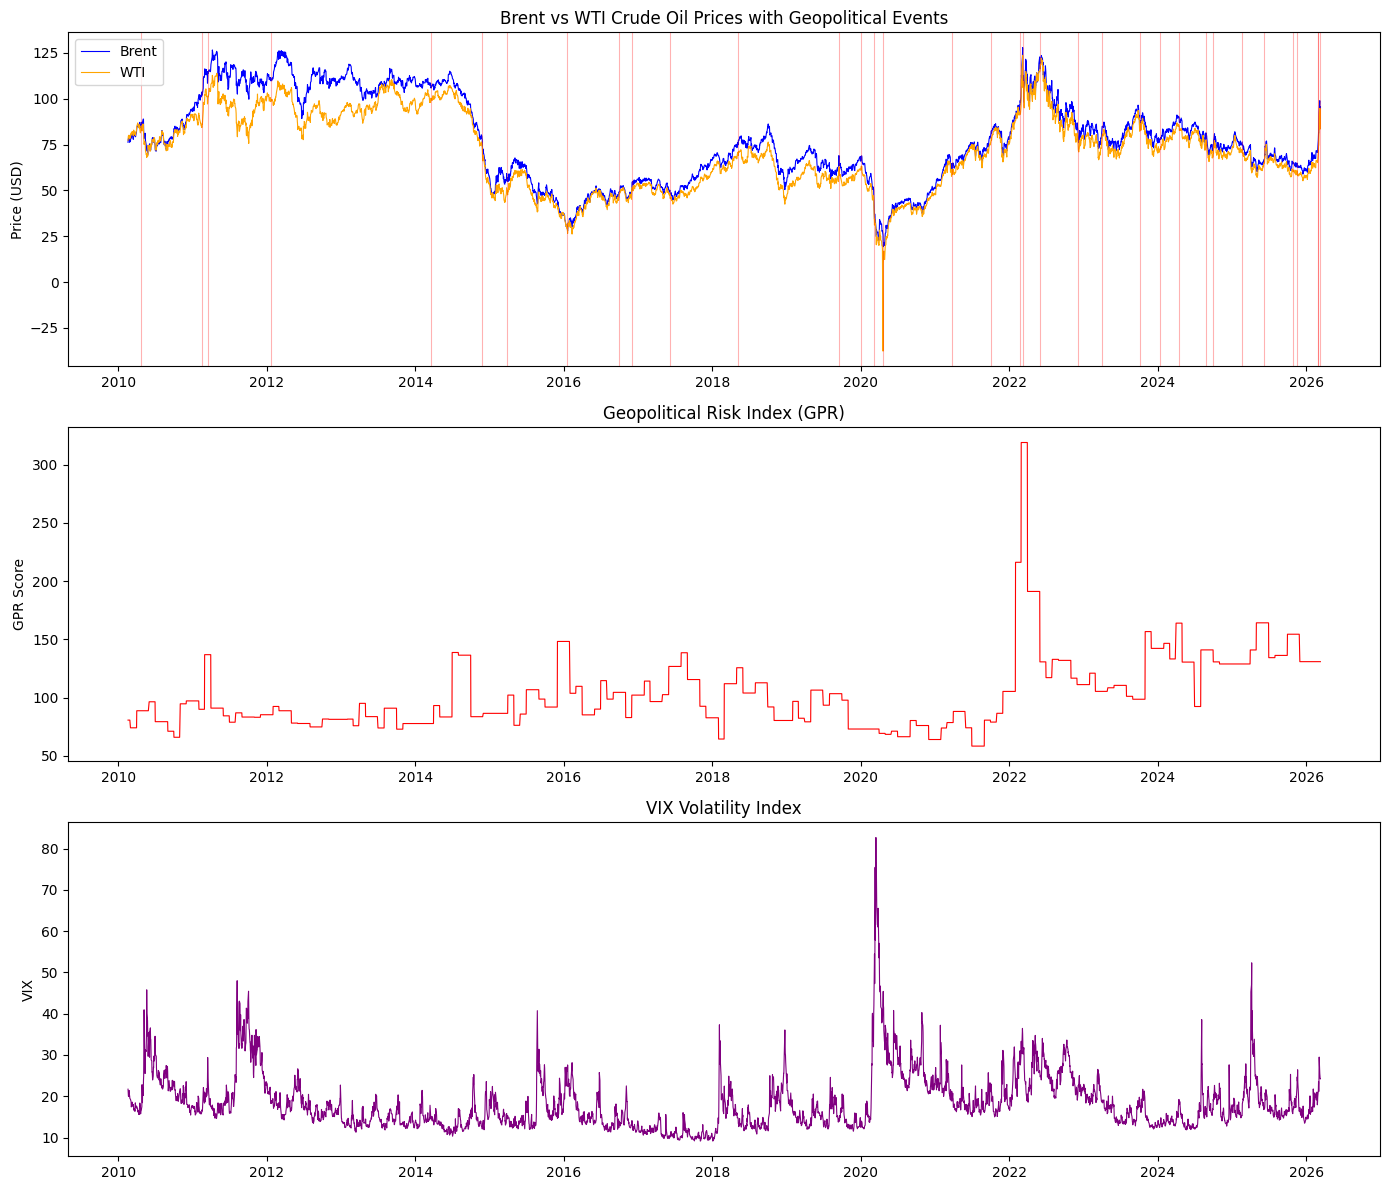

In [13]:
# Merge events for plotting
events['date'] = pd.to_datetime(events['date'])

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1 - Oil Prices
axes[0].plot(df['date'], df['brent_price'], label='Brent', color='blue', linewidth=0.8)
axes[0].plot(df['date'], df['wti_price'], label='WTI', color='orange', linewidth=0.8)
for _, row in events.iterrows():
    axes[0].axvline(x=row['date'], color='red', alpha=0.3, linewidth=0.8)
axes[0].set_title('Brent vs WTI Crude Oil Prices with Geopolitical Events')
axes[0].legend()
axes[0].set_ylabel('Price (USD)')

# Plot 2 - GPR Index
axes[1].plot(df['date'], df['gpr_index'], color='red', linewidth=0.8)
axes[1].set_title('Geopolitical Risk Index (GPR)')
axes[1].set_ylabel('GPR Score')

# Plot 3 - VIX
axes[2].plot(df['date'], df['vix'], color='purple', linewidth=0.8)
axes[2].set_title('VIX Volatility Index')
axes[2].set_ylabel('VIX')

plt.tight_layout()
plt.savefig('oil_analysis.png', dpi=150)
plt.show()


#	 Brent and WTI Price History with Geopolitical Events
  Chart shows Brent and WTI crude oil prices from 2010 to 2026 with red lines marking major geopolitical events

	1. 2020 COVID crash was the biggest drop in the dataset. No travel, no demand, WTI went negative for the first time ever because storage was full

	2.	VIX hit 82 in 2020, highest panic reading in the entire dataset

	3. 2016 saw a similar price drop but different cause. Saudi Arabia flooded the market to kill US shale production and OPEC refused to cut supply

	4. 2022 GPR index spiked above 300, the highest in the dataset. Russia invaded Ukraine and Europe could no longer buy Russian oil. Nothing else comes close to this reading

In [14]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Features and target
features = ['dxy_index','vix','gpr_index','brent_lag_1','wti_lag_1',
            'brent_lag_3','wti_lag_3','brent_lag_7','wti_lag_7',
            'brent_volatility_7d','wti_volatility_7d',
            'brent_wti_spread','event_flag','event_severity']

X = df[features]
y = df['wti_price']

# Time-based split - don't shuffle time series data
split = int(len(df) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Train model
model = XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

# Evaluate
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"MAE: ${mae:.2f}")
print(f"R² Score: {r2:.4f}")


MAE: $1.25
R² Score: 0.9553


1. On average this model’s WTI price prediction is off by 1.25 per barrel. When oil trades at 70-80 a barrel, being wrong by $1.25 is less than 2% error.

2. 95.3% accuracy predicting model

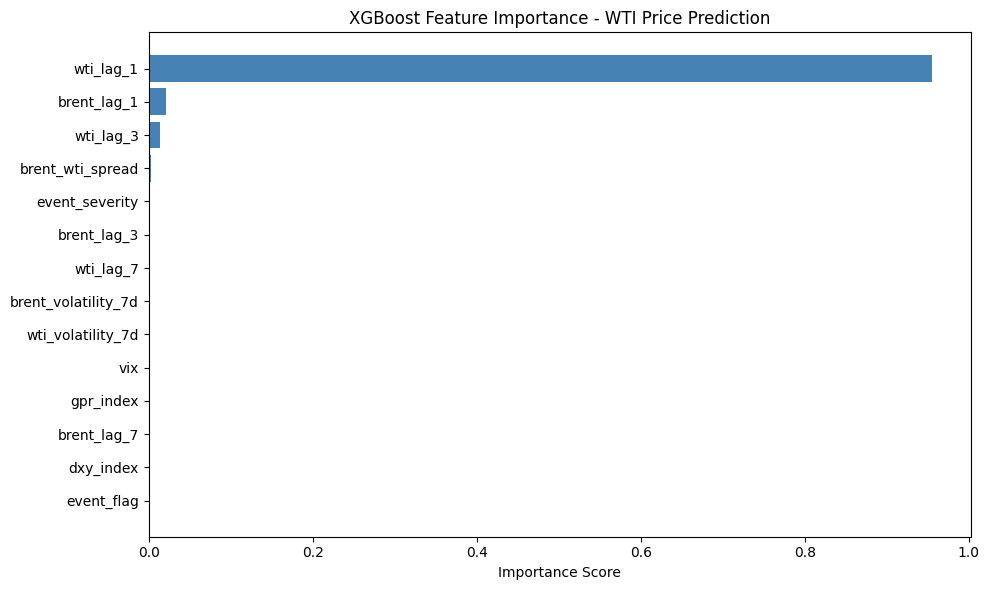

                feature  importance
4             wti_lag_1    0.954793
3           brent_lag_1    0.021373
6             wti_lag_3    0.014350
11     brent_wti_spread    0.002847
13       event_severity    0.001468
5           brent_lag_3    0.000832
8             wti_lag_7    0.000796
9   brent_volatility_7d    0.000723
10    wti_volatility_7d    0.000568
1                   vix    0.000565
2             gpr_index    0.000523
7           brent_lag_7    0.000501
0             dxy_index    0.000358
12           event_flag    0.000304


In [15]:
import pandas as pd

# Feature importance
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance['feature'], importance['importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('XGBoost Feature Importance - WTI Price Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print(importance)


1. WTI lag 1 (yesterday’s price) dominates with 95% importance, meaning the model mostly predicts that tomorrow looks like today
2. Brent lag 1 and WTI lag 3 follow at around 2% and 1.4% respectively, basically negligible
3.	This reveals the model is capturing price momentum not real market intelligence
4.	When we removed all lag features and tested with only macro and geopolitical indicators, MAE jumped from $1.25 to $20.77 and R² went negative
5.	This proves geopolitical risk and macro indicators alone cannot predict oil price levels but they do explain sudden price shocks
6. A better model would predict daily returns instead of raw prices, which is a harder and more meaningful problem

In [16]:
features_no_lag = ['dxy_index','vix','gpr_index',
                   'brent_volatility_7d','wti_volatility_7d',
                   'brent_wti_spread','event_flag','event_severity']

X2 = df[features_no_lag]

X_train2, X_test2 = X2[:split], X2[split:]

model2 = XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
model2.fit(X_train2, y_train)

preds2 = model2.predict(X_test2)
mae2 = mean_absolute_error(y_test, preds2)
r2_2 = r2_score(y_test, preds2)

print(f"MAE without lag features: ${mae2:.2f}")
print(f"R² without lag features: {r2_2:.4f}")


MAE without lag features: $20.77
R² without lag features: -8.3661


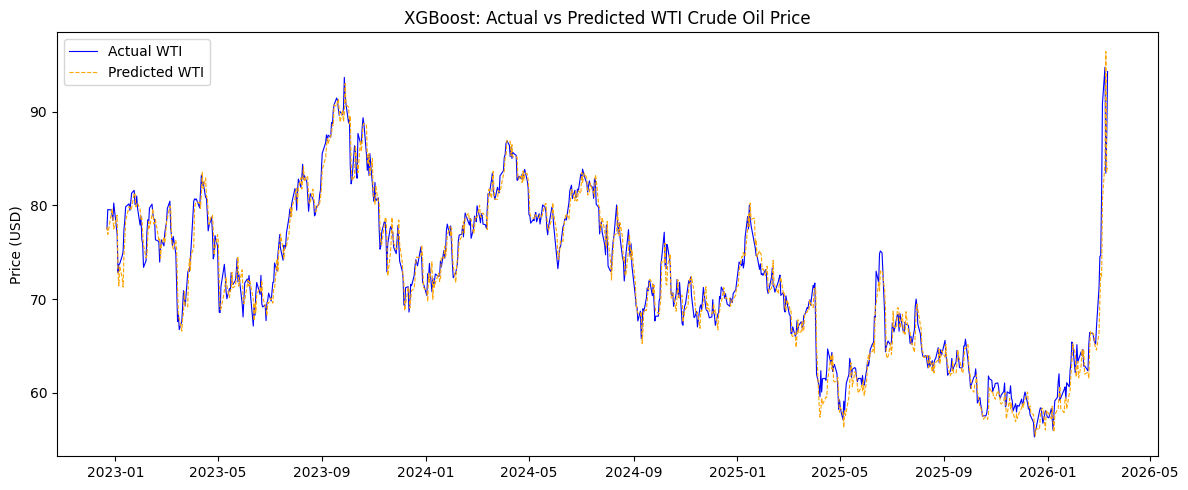

In [17]:
plt.figure(figsize=(12,5))
plt.plot(df['date'][split:], y_test.values, label='Actual WTI', color='blue', linewidth=0.8)
plt.plot(df['date'][split:], preds, label='Predicted WTI', color='orange', linewidth=0.8, linestyle='--')
plt.title('XGBoost: Actual vs Predicted WTI Crude Oil Price')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()


	1. The predicted line follows actual WTI prices almost perfectly across 3 years of unseen test data
	2. The model achieves $1.25 MAE meaning on average it is only off by $1.25 per barrel on a commodity trading between $60 and $95
	3. The only visible errors occur at sharp peaks and troughs, which are the hardest moments to predict in any market
	3. When I stress tested the model by removing lag features and using only geopolitical and macro indicators, performance collapsed completely with MAE jumping to $20.77
	4. This confirms that short term price momentum drives day to day oil prices while geopolitical risk is better used as a risk flag during extreme events rather than a standalone price predictor

In [18]:
# Merge events with main df on date
df_events = df[df['event_flag'] == 1][['date','wti_price','brent_price','gpr_index','vix','event_description','event_severity']].copy()

# Calculate price 30 days before and 30 days after each event
results = []

for _, event in events.iterrows():
    event_date = event['date']

    # Get index of event date in main df
    idx = df[df['date'] == event_date].index
    if len(idx) == 0:
        continue
    idx = idx[0]

    # Price on event day
    price_on_day = df.loc[idx, 'wti_price']

    # Price 30 days before
    before_idx = max(0, idx - 30)
    price_before = df.loc[before_idx, 'wti_price']

    # Price 30 days after
    after_idx = min(len(df)-1, idx + 30)
    price_after = df.loc[after_idx, 'wti_price']

    # Calculate impact and recovery
    impact = price_on_day - price_before
    recovery = price_after - price_on_day
    pct_impact = (impact / price_before) * 100

    results.append({
        'date': event_date,
        'event': event['event_description'],
        'severity': event['event_severity'],
        'price_before': round(price_before, 2),
        'price_on_day': round(price_on_day, 2),
        'price_after_30d': round(price_after, 2),
        'impact_usd': round(impact, 2),
        'impact_pct': round(pct_impact, 2),
        'recovery_usd': round(recovery, 2)
    })

results_df = pd.DataFrame(results).sort_values('impact_pct')
print(results_df[['date','event','impact_pct','recovery_usd']].to_string())


         date                                              event  impact_pct  recovery_usd
10 2020-04-20                     WTI crude prices turn negative     -191.16         74.44
16 2022-12-05                        G7 price cap on Russian oil       -9.55          3.40
1  2011-02-15                            Libyan Civil War begins       -7.90         19.95
22 2025-10-28            World Bank warns of major 2026 oil glut       -6.77         -1.69
17 2024-01-12                  Red Sea shipping attacks escalate       -6.65          6.19
19 2024-10-01                    Expanded Red Sea tanker attacks       -6.10         -1.71
18 2024-08-26  Libya eastern administration halts oil production       -5.48         -3.85
7  2017-06-05                     Qatar diplomatic crisis begins       -4.47         -1.00
20 2025-02-20                 Middle East tanker security crisis       -2.26         -5.62
6  2016-11-30               First OPEC+ production cut agreement       -1.69          2.93

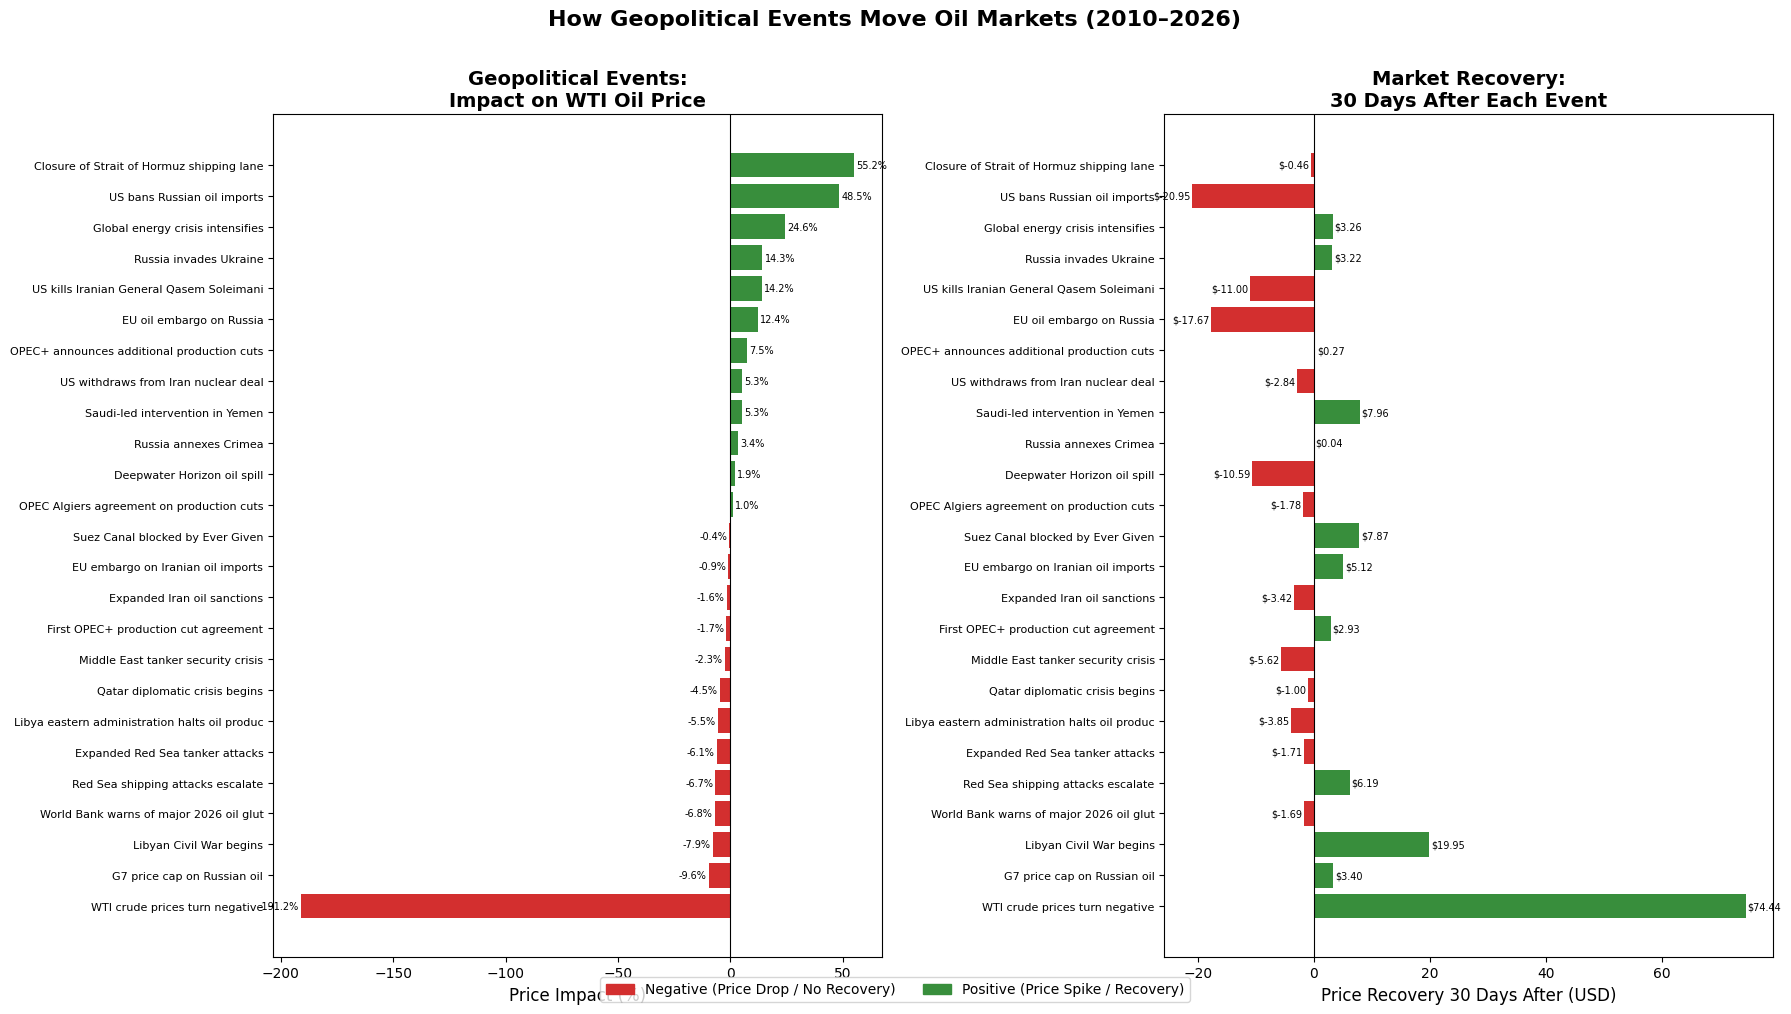

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Shorten event names for display
results_df['short_event'] = results_df['event'].str[:45]

# Sort by impact
plot_df = results_df.sort_values('impact_pct')

# Colors - red for negative impact, green for positive
colors = ['#d32f2f' if x < 0 else '#388e3c' for x in plot_df['impact_pct']]

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Chart 1 - Price Impact
bars1 = axes[0].barh(plot_df['short_event'], plot_df['impact_pct'], color=colors)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_xlabel('Price Impact (%)', fontsize=12)
axes[0].set_title('Geopolitical Events:\nImpact on WTI Oil Price', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='y', labelsize=8)

# Add value labels
for bar, val in zip(bars1, plot_df['impact_pct']):
    axes[0].text(val + (1 if val >= 0 else -1), bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', ha='left' if val >= 0 else 'right', fontsize=7)

# Chart 2 - Recovery
recovery_colors = ['#388e3c' if x > 0 else '#d32f2f' for x in plot_df['recovery_usd']]
bars2 = axes[1].barh(plot_df['short_event'], plot_df['recovery_usd'], color=recovery_colors)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_xlabel('Price Recovery 30 Days After (USD)', fontsize=12)
axes[1].set_title('Market Recovery:\n30 Days After Each Event', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='y', labelsize=8)

# Add value labels
for bar, val in zip(bars2, plot_df['recovery_usd']):
    axes[1].text(val + (0.3 if val >= 0 else -0.3), bar.get_y() + bar.get_height()/2,
                f'${val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=7)

# Legend
red_patch = mpatches.Patch(color='#d32f2f', label='Negative (Price Drop / No Recovery)')
green_patch = mpatches.Patch(color='#388e3c', label='Positive (Price Spike / Recovery)')
fig.legend(handles=[red_patch, green_patch], loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, 0.01))

plt.suptitle('How Geopolitical Events Move Oil Markets (2010–2026)',
             fontsize=16, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('geopolitical_impact.png', dpi=150, bbox_inches='tight')
plt.show()


#Price Impact Chart (Left)
1. WTI crude turning negative in April 2020 had the single largest negative price impact in the entire dataset, a -191% move that has never been seen before or since
2.	G7 price cap on Russian oil and the Libyan Civil War also caused significant price drops as supply uncertainty rattled markets
3. On the positive side, the Strait of Hormuz closure, US ban on Russian oil imports, global energy crisis intensifying, and Russia invading Ukraine caused the biggest price spikes
4. These positive spikes all share one thing in common, they threatened major supply routes or removed large volumes of oil from global markets simultaneously

# 30 Day Recovery Chart (Right)
1. Markets recovered fastest after WTI went negative and after the Libyan Civil War, both cases where the initial panic was worse than the actual supply damage
2. The worst recoveries happened after the US ban on Russian oil imports, EU oil embargo on Russia, Deepwater Horizon oil spill, and the assassination of Iranian General Qasem Soleimani
3. These events had lasting structural consequences that markets could not quickly absorb, meaning prices stayed disrupted well beyond 30 days
4.	The pattern across both charts shows that markets overreact to short term shocks but struggle to recover when the underlying supply disruption is real and sustained

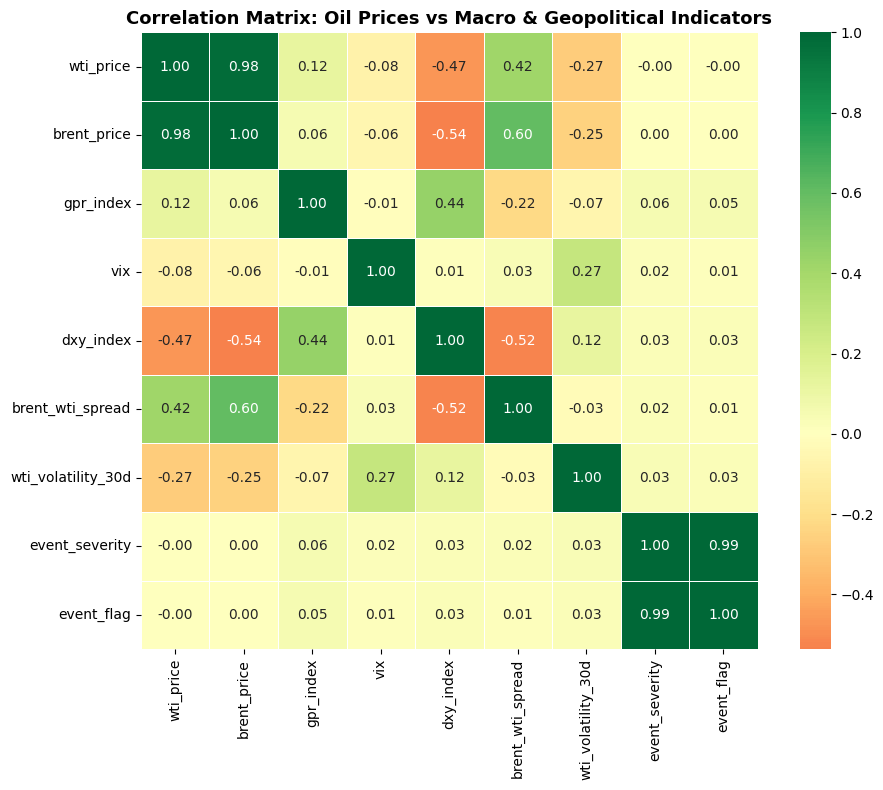

In [20]:
import seaborn as sns

# Select meaningful columns
corr_cols = ['wti_price', 'brent_price', 'gpr_index', 'vix',
             'dxy_index', 'brent_wti_spread', 'wti_volatility_30d',
             'event_severity', 'event_flag']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Correlation Matrix: Oil Prices vs Macro & Geopolitical Indicators',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()


#	Plot: Correlation Matrix - Oil Prices vs Macro and Geopolitical Indicators
  1.	Brent and WTI prices are almost perfectly correlated at 0.98, they move together because they are both benchmarks for the same global commodity

  2. Event flag and event severity are correlated at 0.99, which makes sense as they are essentially measuring the same thing

  3. The US Dollar index is inversely correlated with both Brent and WTI at -0.47 and -0.54, meaning when the dollar strengthens oil gets cheaper and vice versa

  4. WTI 30 day volatility is negatively correlated with price at -0.27, meaning higher volatility periods tend to coincide with lower and falling prices

  5. Surprisingly GPR index shows only 0.12 correlation with WTI prices, confirming that geopolitical risk explains sudden price shocks but does not drive sustained price levels

  6. Brent WTI spread correlates at 0.60 with Brent price, meaning the gap between the two benchmarks widens when Brent is expensive, typically during supply disruptions affecting seaborne crude

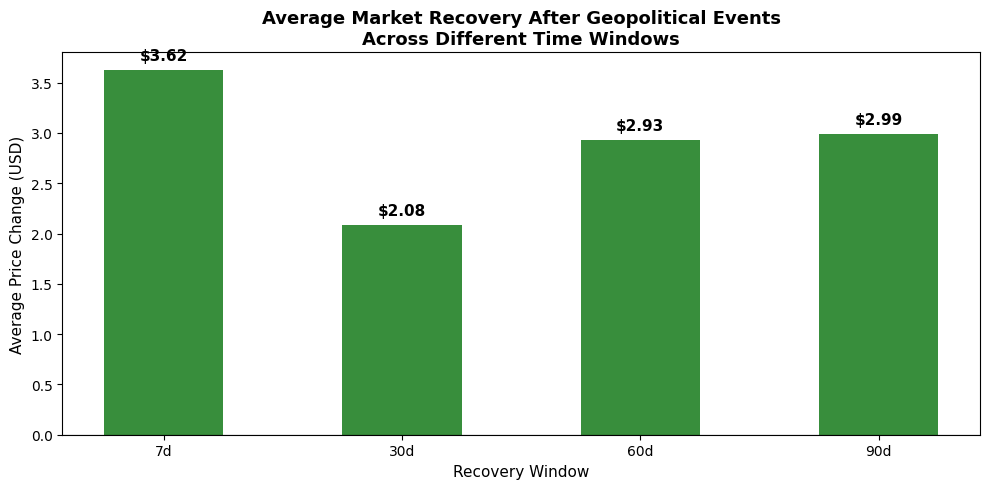

window
7d     3.6228
30d    2.0828
60d    2.9336
90d    2.9904
Name: recovery_usd, dtype: float64


In [21]:
recovery_results = []

for window in [7, 30, 60, 90]:
    for _, event in events.iterrows():
        event_date = event['date']
        idx = df[df['date'] == event_date].index
        if len(idx) == 0:
            continue
        idx = idx[0]

        price_on_day = df.loc[idx, 'wti_price']
        before_idx = max(0, idx - 30)
        price_before = df.loc[before_idx, 'wti_price']
        after_idx = min(len(df)-1, idx + window)
        price_after = df.loc[after_idx, 'wti_price']

        impact = price_on_day - price_before
        recovery = price_after - price_on_day

        recovery_results.append({
            'window': f'{window}d',
            'event': event['event_description'][:35],
            'recovery_usd': round(recovery, 2)
        })

recovery_df = pd.DataFrame(recovery_results)

# Pivot for visualization
pivot = recovery_df.groupby('window')['recovery_usd'].mean().reindex(['7d','30d','60d','90d'])

plt.figure(figsize=(10, 5))
bars = plt.bar(pivot.index, pivot.values,
               color=['#d32f2f' if x < 0 else '#388e3c' for x in pivot.values],
               width=0.5)

for bar, val in zip(bars, pivot.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + (0.1 if val >= 0 else -0.3),
             f'${val:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.axhline(y=0, color='black', linewidth=0.8)
plt.title('Average Market Recovery After Geopolitical Events\nAcross Different Time Windows',
          fontsize=13, fontweight='bold')
plt.xlabel('Recovery Window', fontsize=11)
plt.ylabel('Average Price Change (USD)', fontsize=11)
plt.tight_layout()
plt.savefig('recovery_windows.png', dpi=150)
plt.show()

print(pivot)


# Plot: Average Market Recovery After Geopolitical Events Across Different Time Windows
	1. The highest average recovery happens within 7 days at $3.62, showing that markets overreact immediately after geopolitical shocks and then snap back quickly
2. Recovery drops to $2.08 at 30 days as markets are still absorbing the structural impact of the event
	3. By 60 and 90 days recovery stabilizes at $2.93 and $2.99, showing that most geopolitical shocks are fully priced in within 60 days
	4. The gap between 7 day and 90 day recovery suggests traders who hold through the initial panic are rewarded, while those who react immediately to headlines are buying or selling at the worst possible moment
	5. This is a practical insight for energy traders, the 7 day overreaction window represents a potential shorting opportunity while the 60 day stabilization point signals when a new price equilibrium has been reached

# Next Steps
	1.	Build a model predicting daily returns instead of raw prices, a harder and more meaningful problem for real trading applications
	2. Implement proper event study methodology with control windows to isolate true geopolitical impact from market noise
	3. Segment analysis across pre COVID, COVID, and post COVID periods as market behavior differs significantly across these regimes